In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import seaborn as sns

import mlflow.sklearn

In [3]:
# Load the training dataset used for model development.
work_data = pd.read_csv('../data/processed/train_data.csv')

# Load the independent validation dataset used for final model evaluation.
val_data = pd.read_csv('../data/processed/validation_data.csv')

In [4]:
# Separate the input features from the target variable.
X = work_data.drop(columns=['diabetes'])

# Extract the target variable for model training.
y = work_data['diabetes']

In [5]:
# Split the working dataset into training and test sets.
# Stratify is used to preserve the original class distribution in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [6]:
model_1 = RandomForestClassifier(
    n_estimators=200
)

In [7]:
model_1.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
y_pred = model_1.predict(X_test)

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98     14640
         1.0       0.94      0.68      0.79      1360

    accuracy                           0.97     16000
   macro avg       0.95      0.84      0.89     16000
weighted avg       0.97      0.97      0.97     16000



In [10]:
print(accuracy_score(y_test, y_pred))

0.9691875


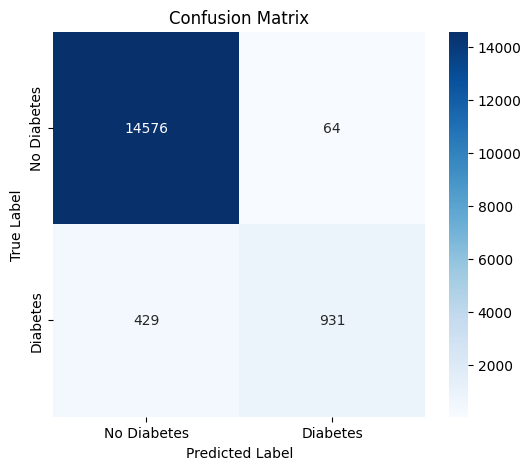

In [11]:
y_pred = model_1.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [12]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("exp_1_diabetes_random_forest")

with mlflow.start_run(run_name="model_1_random_forest"):

    # Predictions with already trained model
    y_pred = model_1.predict(X_test)

    # Log model name
    mlflow.log_param("model", "RandomForestClassifier")

    # Log model parameters automatically
    params = model_1.get_params()

    for key, value in params.items():
        mlflow.log_param(key, value)

    # Log metrics
    mlflow.log_metric("accuracy", metrics.accuracy_score(y_test, y_pred))
    mlflow.log_metric("precision", metrics.precision_score(y_test, y_pred))
    mlflow.log_metric("recall", metrics.recall_score(y_test, y_pred))
    mlflow.log_metric("f1_score", metrics.f1_score(y_test, y_pred))